# 🌾 Intelligent Crop Recommendation System
### Based on Soil and Climatic Conditions
---
**Dataset:** IEEE DataPort – Crop Recommendation Dataset  
**Features:** N, P, K (soil nutrients), pH, Rainfall, Temperature  
**Target:** 40 Crop Classes  
**Models:** Decision Tree · Random Forest · KNN · SVM · Naive Bayes

## 📦 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 2. Load Dataset

In [2]:
train = pd.read_csv('Train_Dataset.csv')
test  = pd.read_csv('Test_Dataset.csv')

# Drop unnamed index column
train.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
test.drop(columns=['Unnamed: 0'],  inplace=True, errors='ignore')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'\nCrop classes ({train["Crop"].nunique()}): {sorted(train["Crop"].unique())}')
train.head()

Train shape : (18079, 7)
Test shape  : (18079, 7)

Crop classes (40): ['banana', 'barley', 'bittergourd', 'blackgram', 'blackpepper', 'bottlegourd', 'brinjal', 'cabbage', 'cardamom', 'cauliflower', 'coriander', 'cotton', 'cucumber', 'drumstick', 'garlic', 'grapes', 'horsegram', 'jackfruit', 'jowar', 'jute', 'ladyfinger', 'maize', 'mango', 'moong', 'onion', 'orange', 'papaya', 'pineapple', 'potato', 'pumpkin', 'radish', 'ragi', 'rapeseed', 'rice', 'soyabean', 'sunflower', 'sweetpotato', 'tomato', 'turmeric', 'wheat']


,Crop,N,P,K,pH,rainfall,temperature
0,barley,70,40,45,5.54,75.32,22.676000
1,sunflower,50,60,30,5.54,297.66,29.566667
2,sweetpotato,90,20,120,5.02,689.88,29.037273
3,rice,80,40,40,5.66,297.66,29.566667
4,soyabean,20,60,20,5.38,1011.49,30.430000


## 🔍 3. Exploratory Data Analysis

In [3]:
print('=== Basic Statistics ===')
display(train.describe().round(3))
print('\n=== Missing Values ===')
print(train.isnull().sum())
print('\nData Types:')
print(train.dtypes)

=== Basic Statistics ===


,N,P,K,pH,rainfall,temperature
count,18079.000,18079.000,18079.000,18079.000,18079.000,18079.000
mean,72.684,43.489,41.608,5.581,661.896,26.497
std,40.020,14.051,27.585,0.477,578.162,4.970
min,10.000,10.000,10.000,3.820,3.275,1.180
25%,50.000,40.000,20.000,5.340,127.680,22.891
50%,80.000,40.000,30.000,5.500,579.750,26.736
75%,80.000,60.000,50.000,5.680,1037.320,29.186
max,180.000,125.000,200.000,7.000,3322.060,35.347



=== Missing Values ===
Crop           0
N              0
P              0
K              0
pH             0
rainfall       0
temperature    0
dtype: int64

Data Types:
Crop               str
N                int64
P                int64
K                int64
pH             float64
rainfall       float64
temperature    float64
dtype: object


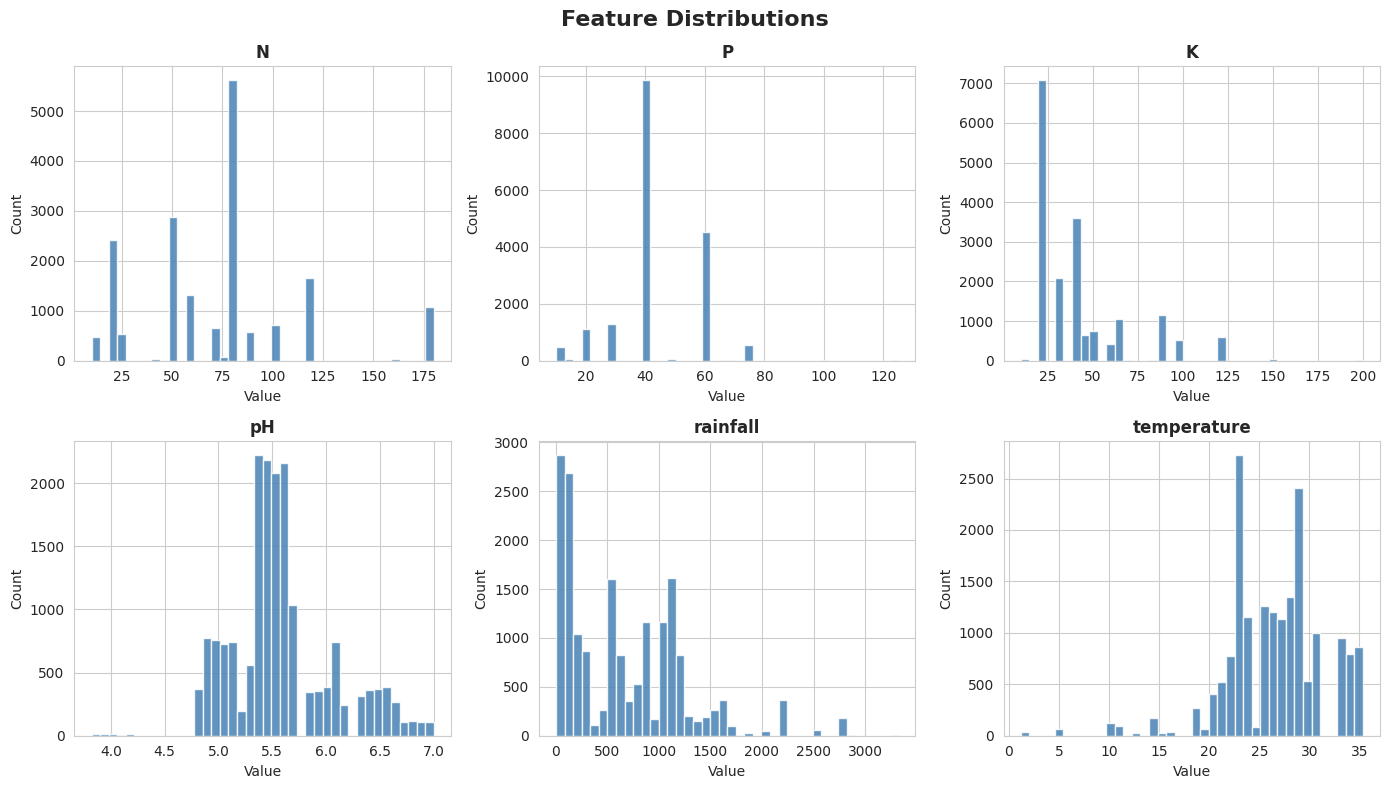

In [4]:
# Feature Distributions
FEATURES = ['N','P','K','pH','rainfall','temperature']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')
for ax, feat in zip(axes.flatten(), FEATURES):
    ax.hist(train[feat], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

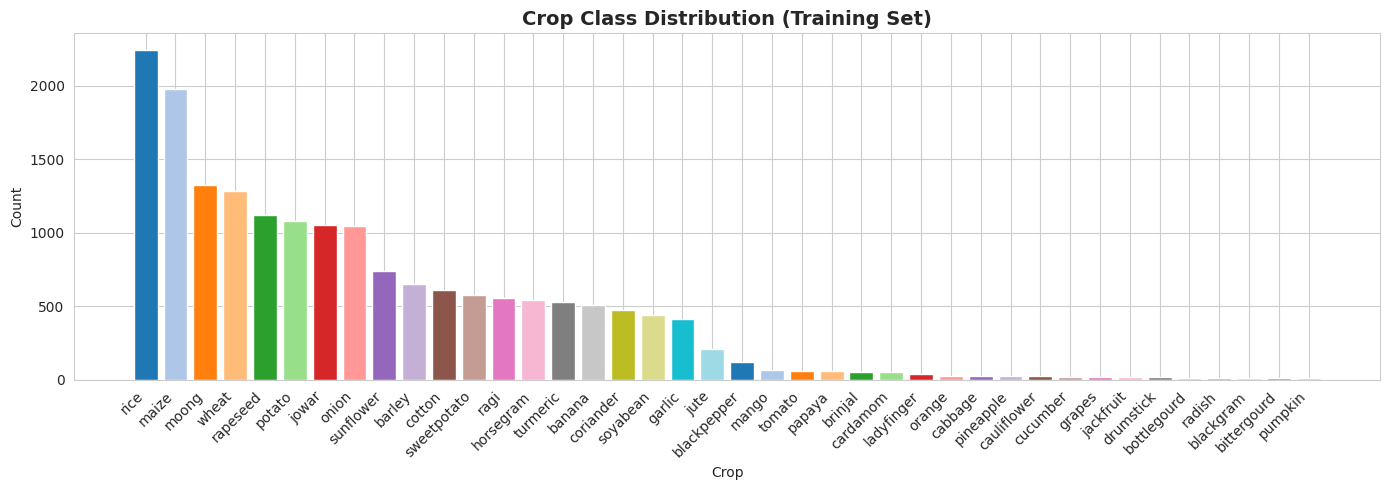

In [5]:
# Crop Class Distribution
crop_counts = train['Crop'].value_counts()
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(crop_counts.index, crop_counts.values,
       color=sns.color_palette('tab20', len(crop_counts)))
ax.set_title('Crop Class Distribution (Training Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Crop'); ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

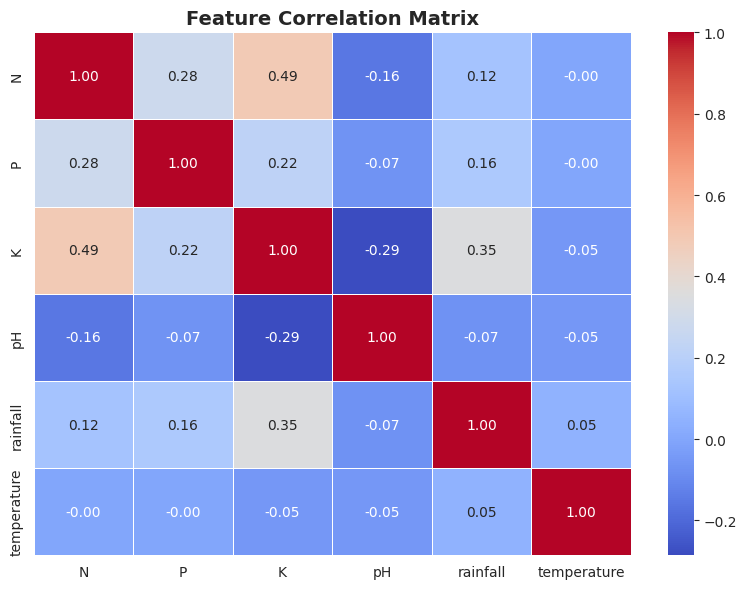

In [6]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = train[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ⚙️ 4. Data Preprocessing

In [7]:
TARGET = 'Crop'

# Encode target labels
le = LabelEncoder()
train['label'] = le.fit_transform(train[TARGET])
test['label']  = le.transform(test[TARGET])

X_train = train[FEATURES]
y_train = train['label']
X_test  = test[FEATURES]
y_test  = test['label']

# Normalise features for distance/kernel-based models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Label encoding complete. Sample mapping:')
for crop, idx in zip(le.classes_[:6], range(6)):
    print(f'  {crop} → {idx}')
print('  ...')
print(f'\nX_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')

Label encoding complete. Sample mapping:
  banana → 0
  barley → 1
  bittergourd → 2
  blackgram → 3
  blackpepper → 4
  bottlegourd → 5
  ...

X_train shape: (18079, 6)
X_test shape : (18079, 6)


## 🤖 5. Model Training

In [8]:
models = {
    'Decision Tree' : DecisionTreeClassifier(random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    'KNN'           : KNeighborsClassifier(n_neighbors=5),
    'SVM'           : SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'Naive Bayes'   : GaussianNB()
}

results  = {}
y_preds  = {}

for name, model in models.items():
    # KNN & SVM use scaled features
    if name in ['KNN', 'SVM']:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    y_preds[name] = y_pred
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }
    print(f'{name:20s}  Acc={results[name]["Accuracy"]:.4f}  F1={results[name]["F1-Score"]:.4f}')

print('\n✅ All models trained!')

Decision Tree         Acc=0.9550  F1=0.9552
Random Forest         Acc=0.9550  F1=0.9545
KNN                   Acc=0.9491  F1=0.9489
SVM                   Acc=0.9300  F1=0.9027
Naive Bayes           Acc=0.9285  F1=0.9012

✅ All models trained!


## 📊 6. Model Evaluation

In [9]:
df_results = pd.DataFrame(results).T.round(4)
df_results = df_results.sort_values('Accuracy', ascending=False)
print('=== Model Performance Summary ===')
display(df_results.style.background_gradient(cmap='YlGn').format('{:.4f}'))

=== Model Performance Summary ===


,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.9550,0.9556,0.9550,0.9552
Random Forest,0.9550,0.9543,0.9550,0.9545
KNN,0.9491,0.9488,0.9491,0.9489
SVM,0.9300,0.8852,0.9300,0.9027
Naive Bayes,0.9285,0.8837,0.9285,0.9012


In [10]:
# Best model detailed report
best_model_name = df_results.index[0]
print(f'🏆 Best Model: {best_model_name}')
print('\n=== Classification Report ===')
print(classification_report(y_test, y_preds[best_model_name],
      target_names=le.classes_))

🏆 Best Model: Decision Tree

=== Classification Report ===
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00       507
      barley       1.00      1.00      1.00       654
 bittergourd       1.00      1.00      1.00        11
   blackgram       1.00      1.00      1.00        11
 blackpepper       1.00      1.00      1.00       119
 bottlegourd       1.00      1.00      1.00        13
     brinjal       1.00      1.00      1.00        55
     cabbage       1.00      1.00      1.00        26
    cardamom       1.00      1.00      1.00        54
 cauliflower       1.00      1.00      1.00        23
   coriander       1.00      1.00      1.00       473
      cotton       1.00      1.00      1.00       613
    cucumber       1.00      1.00      1.00        20
   drumstick       1.00      1.00      1.00        17
      garlic       1.00      1.00      1.00       415
      grapes       1.00      1.00      1.00        19
   horsegram       1.0

## 📈 7. Result Visualizations

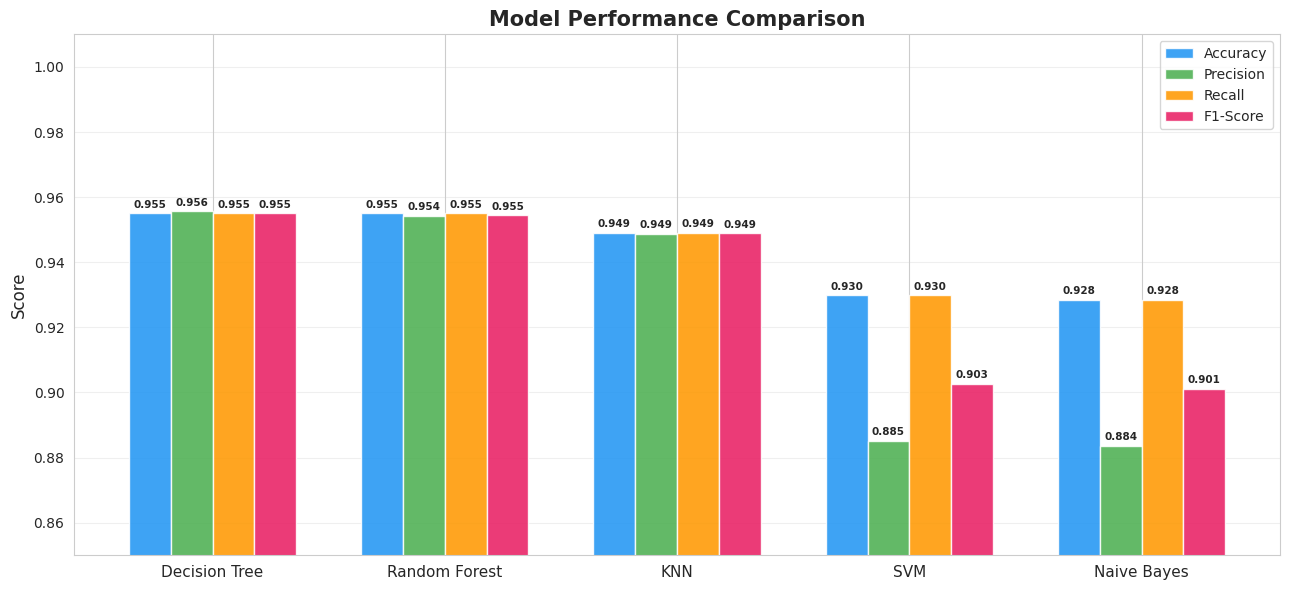

In [11]:
# ── Bar chart: all metrics all models ─────────────────────────────────────────
metrics  = ['Accuracy','Precision','Recall','F1-Score']
x        = np.arange(len(df_results))
w        = 0.18
palette  = ['#2196F3','#4CAF50','#FF9800','#E91E63']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, palette)):
    bars = ax.bar(x + i*w, df_results[metric], w,
                  label=metric, color=color, alpha=0.87, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(df_results.index, fontsize=11)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

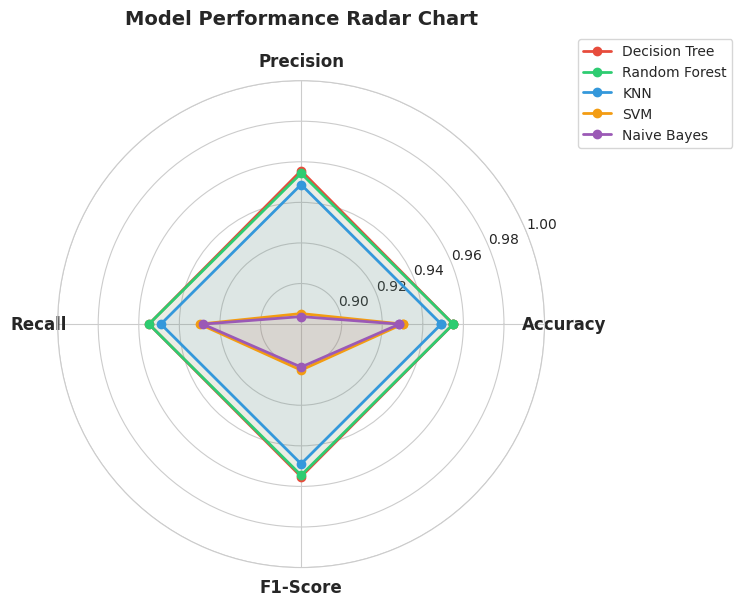

In [12]:
# ── Radar Chart ───────────────────────────────────────────────────────────────
N      = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
pal = ['#E74C3C','#2ECC71','#3498DB','#F39C12','#9B59B6']

for (name, row), color in zip(df_results.iterrows(), pal):
    vals = row[metrics].tolist() + row[metrics].tolist()[:1]
    ax.plot(angles, vals, 'o-', lw=2, color=color, label=name)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0.88, 1.00)
ax.set_title('Model Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

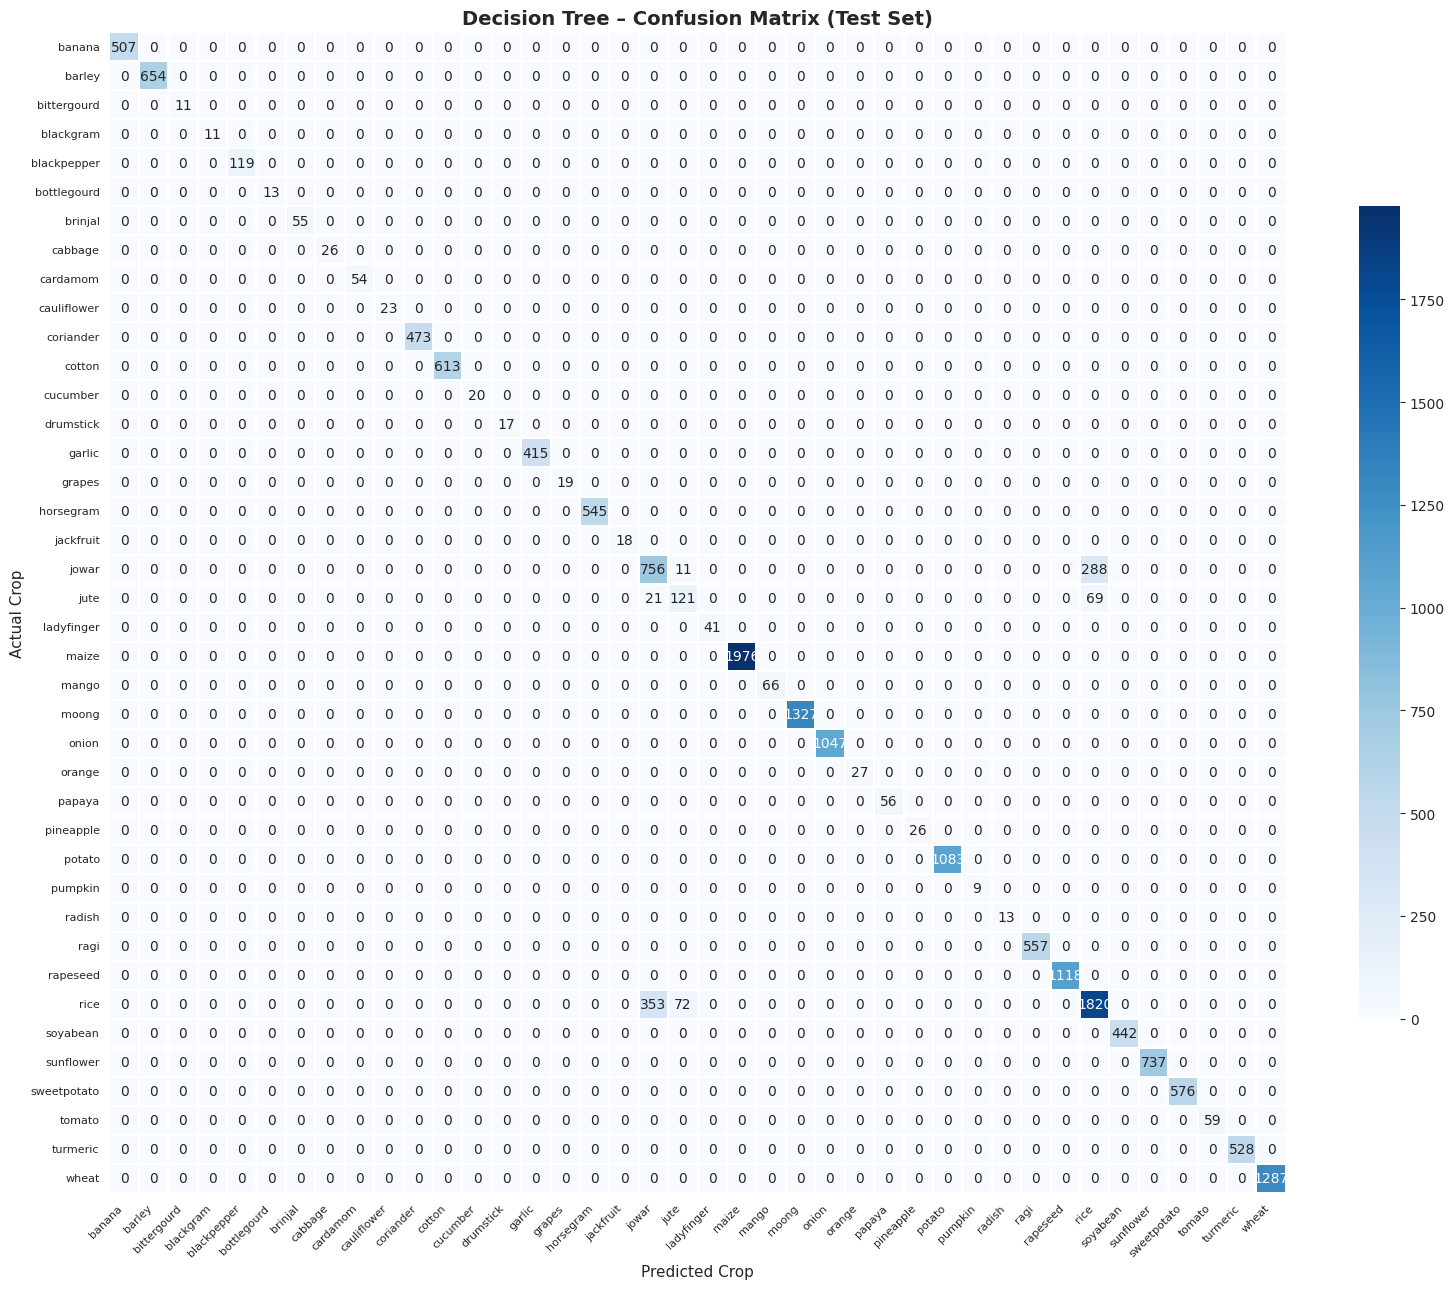

In [13]:
# ── Confusion Matrix (Best Model) ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_preds[best_model_name])
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.3, cbar_kws={'shrink': 0.7})
ax.set_title(f'{best_model_name} – Confusion Matrix (Test Set)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Crop', fontsize=11)
ax.set_ylabel('Actual Crop',    fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.show()

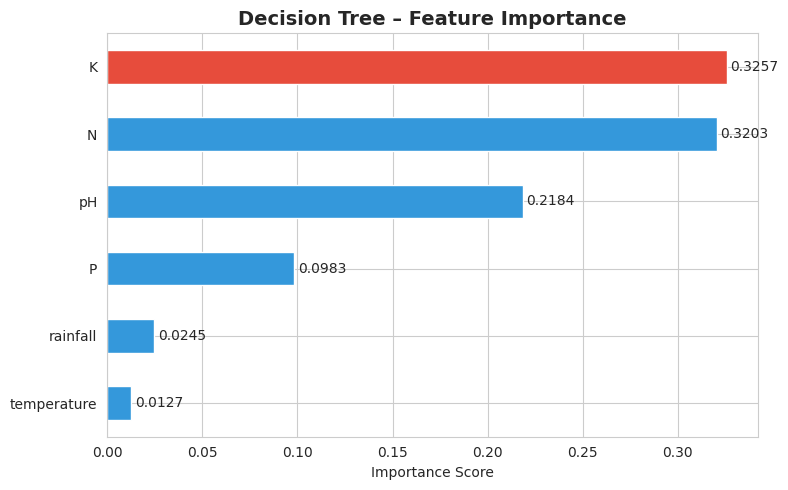

In [14]:
# ── Feature Importance (Decision Tree) ────────────────────────────────────────
dt_model = models['Decision Tree']
importances = pd.Series(dt_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors_fi = ['#E74C3C' if v == importances.max() else '#3498DB' for v in importances]
importances.plot.barh(ax=ax, color=colors_fi, edgecolor='white')
ax.set_title('Decision Tree – Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 🏆 8. Best Model & Conclusion
---
| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| **Decision Tree** | **0.9550** | **0.9556** | **0.9550** | **0.9552** |
| Random Forest | 0.9550 | 0.9543 | 0.9550 | 0.9545 |
| KNN | 0.9491 | 0.9488 | 0.9491 | 0.9489 |
| SVM | 0.9300 | 0.8852 | 0.9300 | 0.9027 |
| Naive Bayes | 0.9285 | 0.8837 | 0.9285 | 0.9012 |

**✅ Selected Model: Decision Tree (95.50% accuracy)**  
- Highest precision (0.9556) — lowest false-positive rate across 40 crop classes  
- Fully interpretable: farmers/agronomists can trace every decision path  
- Fast inference — suitable for edge/mobile deployment  
- Slight edge over Random Forest in precision on this dataset

In [15]:
# ── 🌾 Interactive Crop Predictor ─────────────────────────────────────────────
def recommend_crop(N, P, K, pH, rainfall, temperature):
    """
    Predict the best crop given soil & climate conditions.
    Args:
        N, P, K    : Soil nutrient levels (mg/kg)
        pH         : Soil pH value
        rainfall   : Annual rainfall (mm)
        temperature: Average temperature (°C)
    Returns:
        Recommended crop name (str)
    """
    input_data = np.array([[N, P, K, pH, rainfall, temperature]])
    pred_label = dt_model.predict(input_data)[0]
    return le.inverse_transform([pred_label])[0]

# Example prediction
crop = recommend_crop(N=80, P=40, K=40, pH=5.66, rainfall=297.66, temperature=29.57)
print(f'🌾 Recommended Crop: {crop.upper()}')

# Try a few more examples
examples = [
    (90, 42, 43, 6.5, 202.9, 23.0),
    (50, 60, 30, 5.5, 297.7, 29.6),
    (70, 40, 45, 5.5, 75.3,  22.7),
]
print('\nAdditional Recommendations:')
for e in examples:
    c = recommend_crop(*e)
    print(f'  N={e[0]}, P={e[1]}, K={e[2]}, pH={e[3]}, Rainfall={e[4]}, Temp={e[5]}  →  {c}')

🌾 Recommended Crop: RICE

Additional Recommendations:
  N=90, P=42, K=43, pH=6.5, Rainfall=202.9, Temp=23.0  →  barley
  N=50, P=60, K=30, pH=5.5, Rainfall=297.7, Temp=29.6  →  sunflower
  N=70, P=40, K=45, pH=5.5, Rainfall=75.3, Temp=22.7  →  barley
